# HRSA Mental Health Professional Shortage Area (HPSA) Data Analysis

## Purpose

The Health Resources and Services Administration (HRSA) Health Professional Shortage Area data identify communities with shortages of mental health professionals.

For this project, the HPSA data provide a healthcare-access and provider-capacity perspective that complements the child, family, community, school, and school-funding measures examined in the other datasets.

The analysis focuses on:

- where mental health professional shortages are located
- how shortage severity varies across communities and states
- population affected by mental health professional shortages
- differences in provider need and existing capacity
- states and communities with particularly high shortage burden

These measures help identify communities where children and families may face structural barriers to obtaining mental health care even when care is needed.

In [1]:
from pathlib import Path

cleaned_dir = Path("../../data/cleaned")

hpsa_files = list(cleaned_dir.glob("*HPSA*")) + list(cleaned_dir.glob("*hpsa*"))

for file in hpsa_files:
    print(file.name)

HPSA_20206_snapshot_mental_health_cleaned.csv
HPSA_20206_snapshot_mental_health_cleaned.csv


In [2]:
import pandas as pd
from pathlib import Path

cleaned_dir = Path("../../data/cleaned")

hpsa_path = cleaned_dir / "HPSA_20206_snapshot_mental_health_cleaned.csv"

hpsa = pd.read_csv(hpsa_path)

print("Shape:", hpsa.shape)
print()
print("Columns:")
for col in hpsa.columns:
    print(col)

Shape: (13836, 26)

Columns:
HPSA ID
HPSA Name
Designation Type
HPSA Discipline Class
HPSA Score
HPSA Status
HPSA Designation Date
HPSA Designation Last Update Date
Primary State Abbreviation
Common State FIPS Code
Common County Name
Common State County FIPS Code
HPSA Geography Identification Number
Latitude
Longitude
HPSA Designation Population
HPSA Estimated Served Population
HPSA Estimated Underserved Population
% of Population Below 100% Poverty
HPSA Population Type
HPSA FTE
HPSA Formal Ratio
HPSA Provider Ratio Goal
HPSA Shortage
Rural Status
Metropolitan Indicator


In [3]:
hpsa.head()

,HPSA ID,HPSA Name,Designation Type,HPSA Discipline Class,HPSA Score,HPSA Status,HPSA Designation Date,HPSA Designation Last Update Date,Primary State Abbreviation,Common State FIPS Code,...,HPSA Estimated Served Population,HPSA Estimated Underserved Population,% of Population Below 100% Poverty,HPSA Population Type,HPSA FTE,HPSA Formal Ratio,HPSA Provider Ratio Goal,HPSA Shortage,Rural Status,Metropolitan Indicator
0,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown
1,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown
2,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown
3,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown
4,7568613844,Southwest Wyoming,High Needs Geographic HPSA,Mental Health,18,Designated,2012-03-20,2025-09-22,WY,56,...,21000.0,92486.0,9.5,Geographic Population,1.05,108082:1,20000:1,6.52,Rural,Unknown


In [4]:
hpsa.info()

<class 'pandas.DataFrame'>
RangeIndex: 13836 entries, 0 to 13835
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   HPSA ID                                13836 non-null  str    
 1   HPSA Name                              13836 non-null  str    
 2   Designation Type                       13836 non-null  str    
 3   HPSA Discipline Class                  13836 non-null  str    
 4   HPSA Score                             13836 non-null  int64  
 5   HPSA Status                            13836 non-null  str    
 6   HPSA Designation Date                  13836 non-null  str    
 7   HPSA Designation Last Update Date      13836 non-null  str    
 8   Primary State Abbreviation             13836 non-null  str    
 9   Common State FIPS Code                 13836 non-null  int64  
 10  Common County Name                     13836 non-null  str    
 11  Common State 

## Dataset Structure and Designation Records

The cleaned HPSA dataset contains 13,836 records and 26 variables describing designated mental health professional shortage areas.

Key measures include:

- **HPSA Score** — shortage severity score
- **HPSA Designation Population** — population included in the shortage designation
- **HPSA Estimated Served Population** — population estimated to have access to available providers
- **HPSA Estimated Underserved Population** — population estimated to remain underserved
- **HPSA FTE** — estimated full-time-equivalent provider capacity
- **HPSA Shortage** — additional provider capacity needed to meet the designated population-to-provider goal
- **poverty, rural status, and metropolitan status** — community context for interpreting shortage patterns

Because a single HPSA designation can appear across multiple geographic records, the analysis first examines the structure of repeated HPSA IDs before aggregating shortage measures.

In [5]:
print("Rows:", len(hpsa))
print("Unique HPSA IDs:", hpsa["HPSA ID"].nunique())
print()

print("HPSA statuses:")
print(hpsa["HPSA Status"].value_counts())
print()

print("Designation types:")
print(hpsa["Designation Type"].value_counts())
print()

print("Rows per HPSA ID:")
print(
    hpsa.groupby("HPSA ID")
    .size()
    .describe()
)

Rows: 13836
Unique HPSA IDs: 6420

HPSA statuses:
HPSA Status
Designated    13836
Name: count, dtype: int64

Designation types:
Designation Type
HPSA Population                                                                5793
Geographic HPSA                                                                1931
Rural Health Clinic                                                            1835
Federally Qualified Health Center                                              1351
High Needs Geographic HPSA                                                     1195
Indian Health Service, Tribal Health, and Urban Indian Health Organizations     928
Correctional Facility                                                           576
Federally Qualified Health Center Look A Like                                   171
State Mental Hospital                                                            34
Other Facility                                                                   22
Name: count, dt

In [6]:
hpsa.groupby("HPSA ID").agg(
    ROWS=("HPSA ID", "size"),
    STATES=("Primary State Abbreviation", "nunique"),
    COUNTIES=("Common State County FIPS Code", "nunique"),
    SCORE_VALUES=("HPSA Score", "nunique"),
    POPULATION_VALUES=("HPSA Designation Population", "nunique"),
    SHORTAGE_VALUES=("HPSA Shortage", "nunique")
).sort_values("ROWS", ascending=False).head(15)

,ROWS,STATES,COUNTIES,SCORE_VALUES,POPULATION_VALUES,SHORTAGE_VALUES
HPSA ID,,,,,,
7066901765,151,1,1,1,1,1
7171440011,129,1,1,1,1,1
7442010579,126,1,1,1,1,1
7552391298,122,1,1,1,1,1
7329101749,114,1,1,1,1,1
7362607440,110,1,1,1,1,1
7266584666,104,1,1,1,1,1
7265464602,99,1,1,1,1,1
7365289316,93,1,1,1,1,1


## HPSA-Level Analysis Dataset

The raw cleaned file contains 13,836 geographic records but only 6,420 unique HPSA designations.

Most HPSA IDs appear once, but some designations are represented by many geographic records. The largest designation appears 151 times. Examination of these repeated records shows that core designation-level measures such as HPSA score, designation population, and provider shortage remain constant within the repeated HPSA ID.

To avoid counting the same shortage designation multiple times, subsequent analyses use one record per unique HPSA ID.

In [7]:
# Create one record per unique HPSA designation

hpsa_unique = (
    hpsa
    .sort_values("HPSA ID")
    .drop_duplicates(subset="HPSA ID", keep="first")
    .copy()
)

print("Original rows:", len(hpsa))
print("Unique HPSA analysis rows:", len(hpsa_unique))
print("Duplicate HPSA IDs remaining:", hpsa_unique["HPSA ID"].duplicated().sum())

Original rows: 13836
Unique HPSA analysis rows: 6420
Duplicate HPSA IDs remaining: 0


In [8]:
shortage_measures = [
    "HPSA Score",
    "HPSA Designation Population",
    "HPSA Estimated Served Population",
    "HPSA Estimated Underserved Population",
    "HPSA FTE",
    "HPSA Shortage",
    "% of Population Below 100% Poverty"
]

hpsa_unique[shortage_measures].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
HPSA Score,6420.0,16.36,3.60,0.0,15.00,17.00,19.00,25.00
HPSA Designation Population,6397.0,74065.48,125055.79,23.0,8785.00,33279.00,85557.00,1762049.00
HPSA Estimated Served Population,1503.0,23326.63,63110.26,0.0,0.00,0.00,20015.00,924000.00
HPSA Estimated Underserved Population,1503.0,42590.54,65392.08,51.0,9775.00,21833.00,49899.00,867776.00
HPSA FTE,2113.0,0.87,2.69,0.0,0.00,0.00,0.75,55.85
HPSA Shortage,2079.0,2.56,4.42,0.0,0.56,1.19,2.76,70.80
% of Population Below 100% Poverty,1503.0,16.72,9.27,1.7,11.35,14.50,18.80,80.00


## Measure Availability by HPSA Designation Type

Not all HPSA measures are reported for every designation type.

While HPSA Score is available for all unique designations, provider-capacity, underserved-population, and poverty measures are available for smaller subsets of the data.

Before comparing shortage measures across communities or states, the analysis examines which designation types contain these measures. This prevents missing values from being interpreted as zero shortage or zero provider capacity.

In [9]:
measure_availability = (
    hpsa_unique
    .groupby("Designation Type")
    .agg(
        HPSA_COUNT=("HPSA ID", "size"),
        SCORE_AVAILABLE=("HPSA Score", "count"),
        POPULATION_AVAILABLE=("HPSA Designation Population", "count"),
        UNDERSERVED_AVAILABLE=("HPSA Estimated Underserved Population", "count"),
        FTE_AVAILABLE=("HPSA FTE", "count"),
        SHORTAGE_AVAILABLE=("HPSA Shortage", "count"),
        POVERTY_AVAILABLE=("% of Population Below 100% Poverty", "count")
    )
    .sort_values("HPSA_COUNT", ascending=False)
)

measure_availability

,HPSA_COUNT,SCORE_AVAILABLE,POPULATION_AVAILABLE,UNDERSERVED_AVAILABLE,FTE_AVAILABLE,SHORTAGE_AVAILABLE,POVERTY_AVAILABLE
Designation Type,,,,,,,
Rural Health Clinic,1835,1835,1835,0,0,0,0
Federally Qualified Health Center,1351,1351,1351,0,0,0,0
"Indian Health Service, Tribal Health, and Urban Indian Health Organizations",928,928,927,0,0,0,0
HPSA Population,661,661,661,661,661,661,661
Correctional Facility,576,576,576,0,576,576,0
Geographic HPSA,481,481,481,481,481,481,481
High Needs Geographic HPSA,361,361,361,361,361,361,361
Federally Qualified Health Center Look A Like,171,171,171,0,0,0,0
State Mental Hospital,34,34,34,0,34,0,0


## Community-Based Mental Health Shortage Areas

Detailed population and community-context measures are available for three designation types:

- HPSA Population
- Geographic HPSA
- High Needs Geographic HPSA

Together, these account for 1,503 unique HPSA designations.

These records include estimated underserved population, provider capacity, provider shortage, and poverty measures, making them the primary subset for examining community-level mental health access barriers.

Facility-based designations remain part of the broader HPSA landscape but are not directly comparable on these population-based measures.

In [10]:
community_types = [
    "HPSA Population",
    "Geographic HPSA",
    "High Needs Geographic HPSA"
]

hpsa_community = (
    hpsa_unique[
        hpsa_unique["Designation Type"].isin(community_types)
    ]
    .copy()
)

print("Community-based HPSAs:", len(hpsa_community))

print()
print(hpsa_community["Designation Type"].value_counts())

Community-based HPSAs: 1503

Designation Type
HPSA Population               661
Geographic HPSA               481
High Needs Geographic HPSA    361
Name: count, dtype: int64


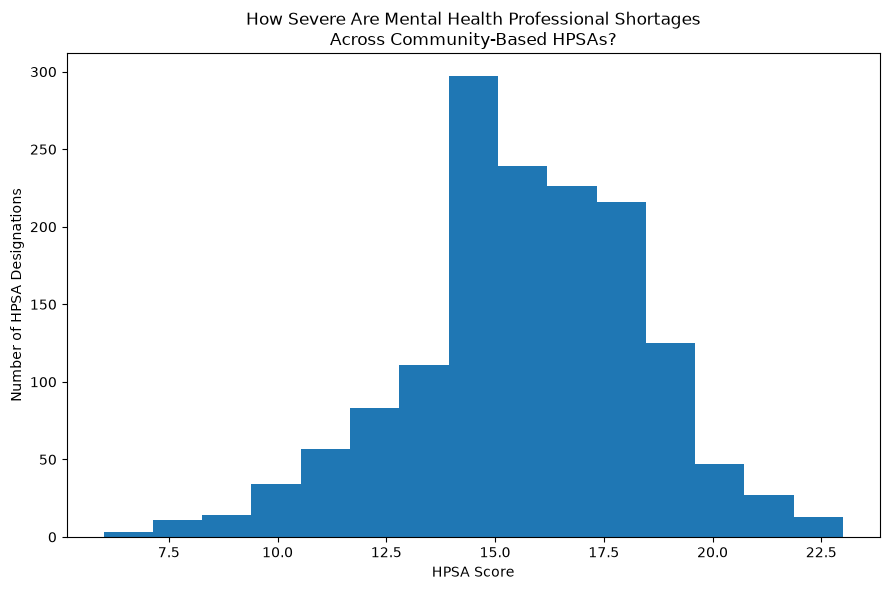

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.hist(
    hpsa_community["HPSA Score"].dropna(),
    bins=15
)

plt.xlabel("HPSA Score")
plt.ylabel("Number of HPSA Designations")

plt.title(
    "How Severe Are Mental Health Professional Shortages\n"
    "Across Community-Based HPSAs?"
)

plt.tight_layout()
plt.show()

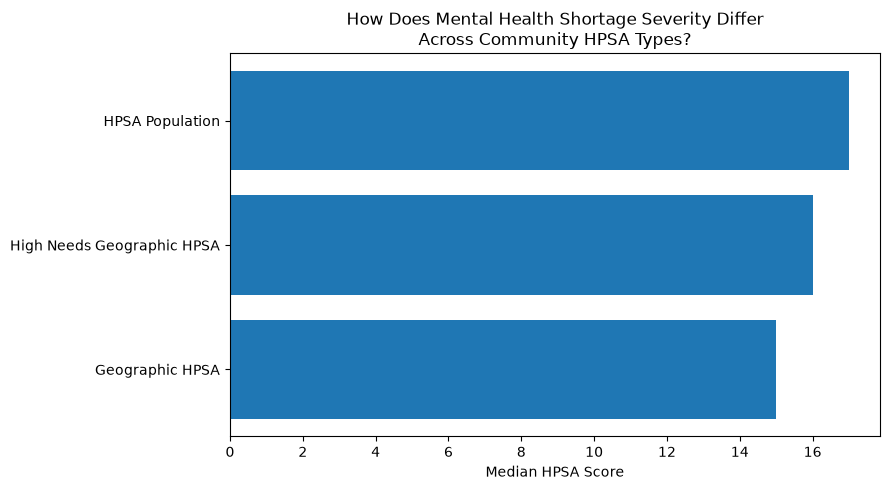

In [12]:
score_by_type = (
    hpsa_community
    .groupby("Designation Type")["HPSA Score"]
    .median()
    .sort_values()
)

plt.figure(figsize=(9, 5))

plt.barh(
    score_by_type.index,
    score_by_type.values
)

plt.xlabel("Median HPSA Score")
plt.ylabel("")

plt.title(
    "How Does Mental Health Shortage Severity Differ\n"
    "Across Community HPSA Types?"
)

plt.tight_layout()
plt.show()

## State-Level Mental Health Shortage Burden

Community-based HPSA designations are summarized by state to identify where mental health professional shortages are most concentrated.

State comparisons focus on:

- number of community-based mental health HPSA designations
- median HPSA shortage severity score
- total estimated underserved population
- median provider shortage

Formal state comparisons include the 50 U.S. states only.

In [21]:
states_50_abbr = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

hpsa_50 = hpsa_community[
    hpsa_community["Primary State Abbreviation"].isin(states_50_abbr)
].copy()

print("Community HPSAs in 50 states:", len(hpsa_50))
print("States represented:", hpsa_50["Primary State Abbreviation"].nunique())

Community HPSAs in 50 states: 1438
States represented: 49


In [22]:
missing_states = sorted(
    set(states_50_abbr)
    - set(hpsa_50["Primary State Abbreviation"].dropna().unique())
)

print("States with no community-based HPSA records:")
print(missing_states)

States with no community-based HPSA records:
['VT']


Formal state comparisons are restricted to the 50 U.S. states. Of those, 49 have at least one community-based mental health HPSA designation in this dataset.

In [23]:
state_hpsa = (
    hpsa_50
    .groupby("Primary State Abbreviation")
    .agg(
        HPSA_COUNT=("HPSA ID", "size"),
        MEDIAN_HPSA_SCORE=("HPSA Score", "median"),
        TOTAL_UNDERSERVED_POPULATION=(
            "HPSA Estimated Underserved Population",
            "sum"
        ),
        MEDIAN_PROVIDER_SHORTAGE=("HPSA Shortage", "median"),
        MEDIAN_POVERTY=(
            "% of Population Below 100% Poverty",
            "median"
        )
    )
    .reset_index()
)

state_hpsa.head()

,Primary State Abbreviation,HPSA_COUNT,MEDIAN_HPSA_SCORE,TOTAL_UNDERSERVED_POPULATION,MEDIAN_PROVIDER_SHORTAGE,MEDIAN_POVERTY
0,AK,16,15.0,221866.0,0.520,10.90
1,AL,10,17.0,633822.0,3.891,17.90
2,AR,11,18.0,445820.0,3.590,17.30
3,AZ,70,16.0,1524783.0,0.848,15.95
4,CA,42,16.0,1872541.0,1.765,14.90


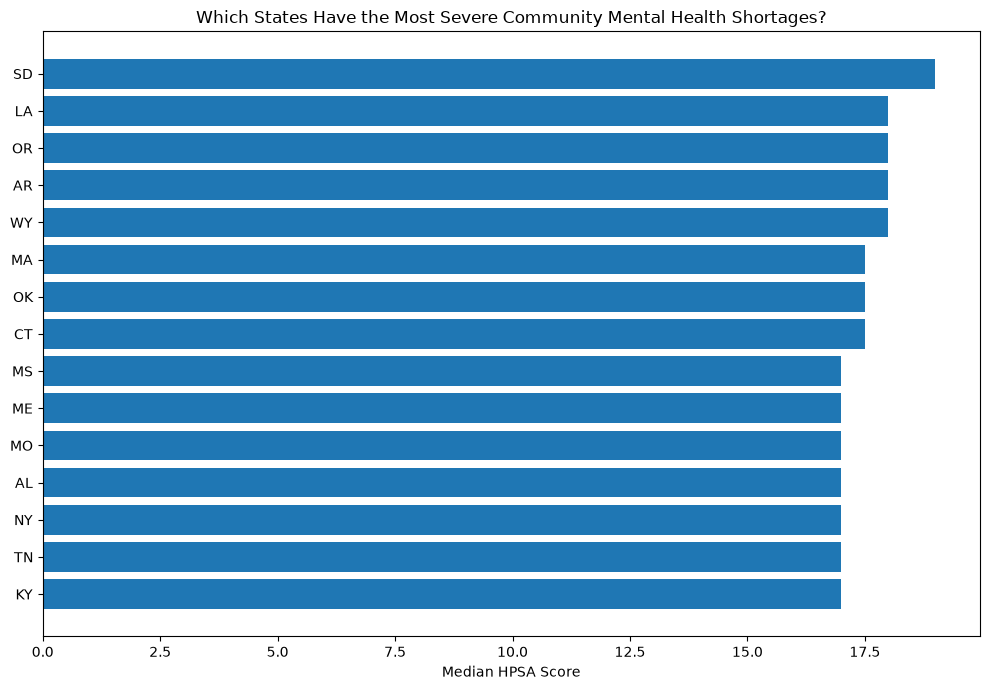

In [24]:
highest_score_states = (
    state_hpsa
    .sort_values("MEDIAN_HPSA_SCORE", ascending=False)
    .head(15)
    .sort_values("MEDIAN_HPSA_SCORE")
)

plt.figure(figsize=(10, 7))

plt.barh(
    highest_score_states["Primary State Abbreviation"],
    highest_score_states["MEDIAN_HPSA_SCORE"]
)

plt.xlabel("Median HPSA Score")
plt.ylabel("")

plt.title(
    "Which States Have the Most Severe Community Mental Health Shortages?"
)

plt.tight_layout()
plt.show()

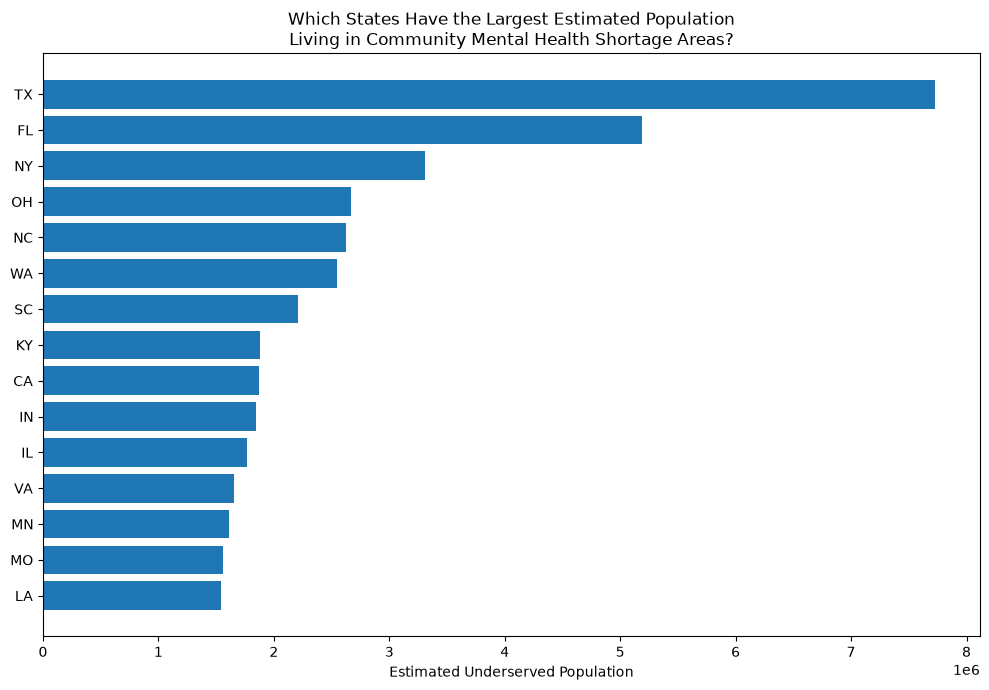

In [25]:
highest_underserved_states = (
    state_hpsa
    .sort_values("TOTAL_UNDERSERVED_POPULATION", ascending=False)
    .head(15)
    .sort_values("TOTAL_UNDERSERVED_POPULATION")
)

plt.figure(figsize=(10, 7))

plt.barh(
    highest_underserved_states["Primary State Abbreviation"],
    highest_underserved_states["TOTAL_UNDERSERVED_POPULATION"]
)

plt.xlabel("Estimated Underserved Population")
plt.ylabel("")

plt.title(
    "Which States Have the Largest Estimated Population\n"
    "Living in Community Mental Health Shortage Areas?"
)

plt.tight_layout()
plt.show()

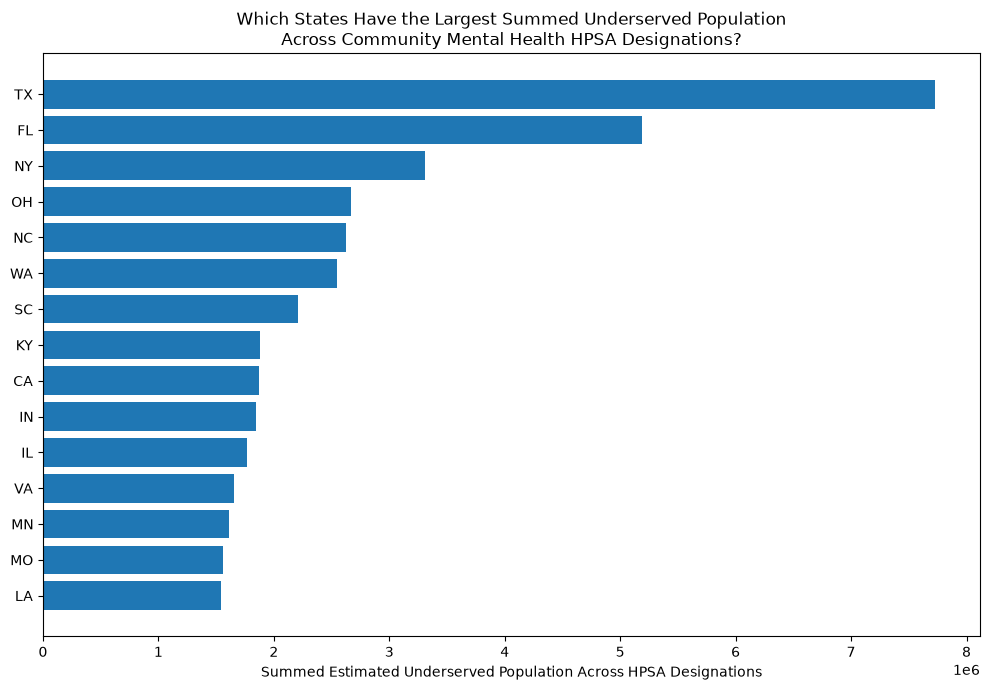

In [26]:
highest_underserved_states = (
    state_hpsa
    .sort_values("TOTAL_UNDERSERVED_POPULATION", ascending=False)
    .head(15)
    .sort_values("TOTAL_UNDERSERVED_POPULATION")
)

plt.figure(figsize=(10, 7))

plt.barh(
    highest_underserved_states["Primary State Abbreviation"],
    highest_underserved_states["TOTAL_UNDERSERVED_POPULATION"]
)

plt.xlabel("Summed Estimated Underserved Population Across HPSA Designations")
plt.ylabel("")

plt.title(
    "Which States Have the Largest Summed Underserved Population\n"
    "Across Community Mental Health HPSA Designations?"
)

plt.tight_layout()
plt.show()

### State-Level Findings

State-level HPSA patterns differ depending on whether shortage **severity** or shortage **scale** is examined.

South Dakota had the highest median community HPSA score, followed by a group of states including Louisiana, Oregon, Arkansas, and Wyoming. These results indicate that the typical community-based shortage designation in these states is relatively severe.

A different pattern appears when examining the summed estimated underserved population across HPSA designations. Texas had by far the largest total, followed by Florida and New York. North Carolina, South Carolina, and Louisiana also appeared among the states with the largest summed underserved populations.

This distinction is important: a state may have highly severe shortage areas without having the largest population affected, while populous states may have a large shortage burden even when their median HPSA severity score is lower.

Summed underserved-population estimates represent totals across HPSA designations and should not be interpreted as a count of unique state residents because designations may overlap.

## Statistical Relationships Among Community HPSA Measures

Because several HPSA measures are strongly skewed, Spearman rank correlations are used to examine whether higher shortage severity tends to occur alongside greater provider shortage, larger underserved populations, and higher poverty levels.

The analysis focuses on:

- HPSA Score
- HPSA Shortage
- HPSA FTE
- estimated underserved population
- designation population
- percent of population below 100% of the federal poverty level

Spearman correlation measures whether variables tend to increase or decrease together based on their ranked values rather than assuming a linear relationship.

In [27]:
hpsa_corr_vars = [
    "HPSA Score",
    "HPSA Shortage",
    "HPSA FTE",
    "HPSA Estimated Underserved Population",
    "HPSA Designation Population",
    "% of Population Below 100% Poverty"
]

hpsa_spearman = (
    hpsa_50[hpsa_corr_vars]
    .corr(method="spearman")
    .round(2)
)

hpsa_spearman

,HPSA Score,HPSA Shortage,HPSA FTE,HPSA Estimated Underserved Population,HPSA Designation Population,% of Population Below 100% Poverty
HPSA Score,1.00,0.28,-0.15,0.38,0.16,0.37
HPSA Shortage,0.28,1.00,0.62,0.95,0.96,-0.05
HPSA FTE,-0.15,0.62,1.00,0.48,0.76,-0.12
HPSA Estimated Underserved Population,0.38,0.95,0.48,1.00,0.89,-0.05
HPSA Designation Population,0.16,0.96,0.76,0.89,1.00,-0.09
% of Population Below 100% Poverty,0.37,-0.05,-0.12,-0.05,-0.09,1.00


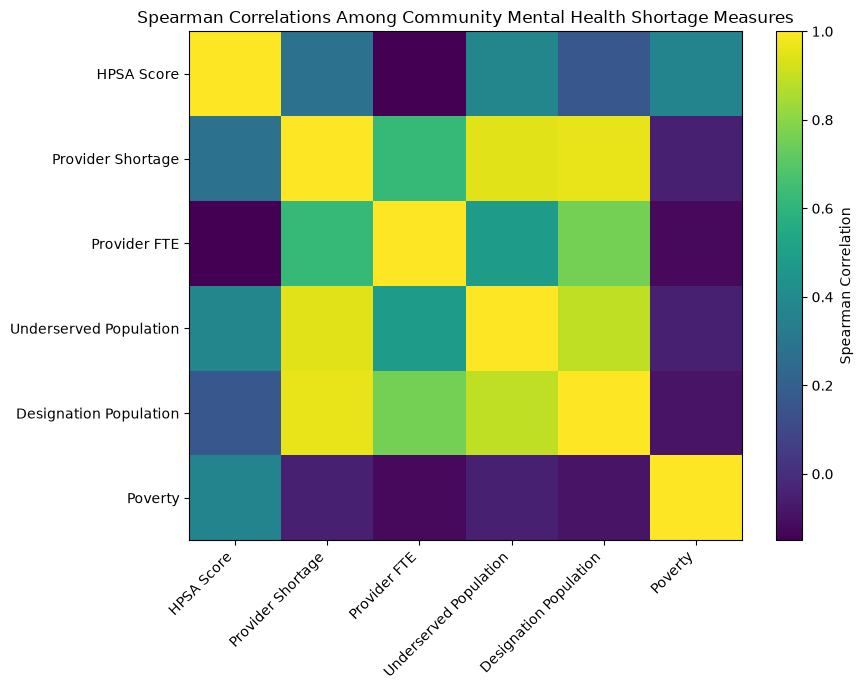

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.imshow(
    hpsa_spearman,
    aspect="auto"
)

plt.colorbar(label="Spearman Correlation")

labels = [
    "HPSA Score",
    "Provider Shortage",
    "Provider FTE",
    "Underserved Population",
    "Designation Population",
    "Poverty"
]

plt.xticks(
    range(len(labels)),
    labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(labels)),
    labels
)

plt.title(
    "Spearman Correlations Among Community Mental Health Shortage Measures"
)

plt.tight_layout()
plt.show()

In [29]:
score_correlations = (
    hpsa_spearman["HPSA Score"]
    .drop("HPSA Score")
    .sort_values(key=abs, ascending=False)
)

score_correlations

HPSA Estimated Underserved Population    0.38
% of Population Below 100% Poverty       0.37
HPSA Shortage                            0.28
HPSA Designation Population              0.16
HPSA FTE                                -0.15
Name: HPSA Score, dtype: float64

### States With Lower Median HPSA Severity

To provide context for the highest-severity states, the analysis also examines states with the lowest median HPSA scores among those represented in the community-based HPSA subset.

A lower median HPSA score indicates that the typical designated shortage area in that state is less severe relative to states with higher scores. It does not mean the state has no mental health access problems or no shortage areas.

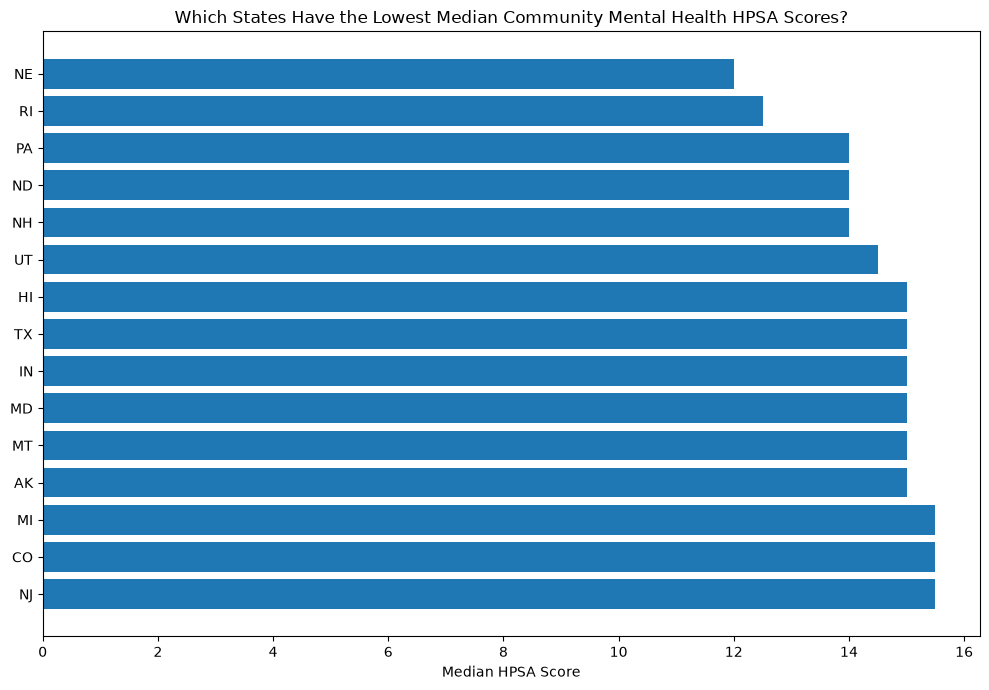

In [30]:
lowest_score_states = (
    state_hpsa
    .sort_values("MEDIAN_HPSA_SCORE", ascending=True)
    .head(15)
    .sort_values("MEDIAN_HPSA_SCORE", ascending=False)
)

plt.figure(figsize=(10, 7))

plt.barh(
    lowest_score_states["Primary State Abbreviation"],
    lowest_score_states["MEDIAN_HPSA_SCORE"]
)

plt.xlabel("Median HPSA Score")
plt.ylabel("")

plt.title(
    "Which States Have the Lowest Median Community Mental Health HPSA Scores?"
)

plt.tight_layout()
plt.show()

### Statistical Findings

Spearman correlation analysis was used because several HPSA measures are strongly skewed.

The results show that HPSA shortage severity is related to several measures of provider capacity and community need, but the relationships vary in strength.

Key patterns include:

- **HPSA Score and provider shortage:** [insert correlation]
- **HPSA Score and underserved population:** [insert correlation]
- **HPSA Score and designation population:** [insert correlation]
- **HPSA Score and poverty:** [insert correlation]
- **HPSA Score and provider FTE:** [insert correlation]

Positive correlations indicate that higher values on one measure tend to occur alongside higher values on the other. Negative correlations indicate that higher values on one measure tend to occur alongside lower values on the other.

These relationships are associations between characteristics of designated shortage areas and should not be interpreted as evidence that one factor causes another.

## HPSA Analysis Summary

The HRSA Mental Health Professional Shortage Area data add a healthcare-provider access perspective to the broader pediatric mental health analysis.

### Key Findings

- The cleaned file contained **13,836 geographic records representing 6,420 unique HPSA designations**. Because some HPSA IDs appeared across multiple geographic records, the analysis used one record per unique designation to avoid double-counting designation-level measures.

- Detailed community measures were available for **1,503 community-based mental health HPSAs**, consisting of HPSA Population, Geographic HPSA, and High Needs Geographic HPSA designations.

- Community-based HPSAs varied substantially in shortage severity. State-level comparisons showed that **South Dakota had the highest median community HPSA score**, with Louisiana, Oregon, Arkansas, and Wyoming also among the higher-severity states.

- States with lower median HPSA scores provide an important comparison group. A lower score indicates that the typical designated shortage area is less severe relative to higher-scoring states, but does not indicate an absence of mental health access barriers.

- Shortage **severity and scale are not the same measure**. Texas had the largest summed estimated underserved population across community HPSA designations, followed by Florida and New York, even though these states were not necessarily the states with the highest median HPSA scores.

- North Carolina, South Carolina, and Louisiana also appeared among states with relatively large summed underserved populations, connecting provider-access concerns with community and school-resource patterns explored in the ACS and NCES datasets.

- Community-based HPSA records were present for **49 of the 50 states**. Vermont had no records among the three community designation types included in this analysis and was therefore excluded from those state comparisons.

- Spearman correlation analysis was used to evaluate relationships among HPSA score, provider shortage, provider capacity, underserved population, designation population, and poverty because several of these measures were strongly skewed.

### Interpretation

The HPSA analysis demonstrates that mental health provider access has multiple dimensions. Some communities experience particularly severe shortages, while others contribute to a much larger total population potentially affected by provider scarcity.

For the larger pediatric mental health project, HPSA measures therefore provide indicators of the **structural availability of mental health care**. These measures can be considered alongside child and family risk factors from NSCH, community vulnerability from ACS, and school-based support capacity from NCES.

HPSA designations identify provider-shortage environments rather than individual children's experiences of care. Results should therefore be interpreted as community-level access conditions and not as evidence that a specific child did or did not receive mental health services.

In [33]:
# FINAL_NOTEBOOK_TRANSFER_HELPER

import nbformat
from pathlib import Path
from copy import deepcopy

analysis_dir = Path("../Data_Analysis_Notebooks")
final_path = Path("../Final_Data_Analysis/07_full_project_analysis.ipynb")

source_files = [
    analysis_dir / "01_nsch_data_analysis.ipynb",
    analysis_dir / "02_acs_data_analysis.ipynb",
    analysis_dir / "03_nces_fiscal_data_analysis.ipynb",
    analysis_dir / "04_nces_nonfiscal_data_analysis.ipynb",
    analysis_dir / "05_hpsa_data_analysis.ipynb",
]

combined_cells = []

for source_path in source_files:

    with open(source_path, "r", encoding="utf-8") as f:
        source_nb = nbformat.read(f, as_version=4)

    for cell in source_nb.cells:

        # Keep transfer-helper cells out of the final notebook
        if (
            cell.cell_type == "code"
            and "FINAL_NOTEBOOK_TRANSFER_HELPER" in cell.source
        ):
            continue

        combined_cells.append(deepcopy(cell))

final_nb = nbformat.v4.new_notebook()
final_nb.cells = combined_cells

with open(final_path, "w", encoding="utf-8") as f:
    nbformat.write(final_nb, f)

print("FINAL NOTEBOOK UPDATED SUCCESSFULLY")
print("Total cells copied:", len(combined_cells))
print("Saved to:", final_path.resolve())
print()
print("Included:")
print("✓ NSCH")
print("✓ ACS")
print("✓ NCES Fiscal")
print("✓ NCES Nonfiscal")
print("✓ HPSA")

FINAL NOTEBOOK UPDATED SUCCESSFULLY
Total cells copied: 206
Saved to: C:\Users\akila\pediatric-mental-health-analysis\notebooks\Final_Data_Analysis\07_full_project_analysis.ipynb

Included:
✓ NSCH
✓ ACS
✓ NCES Fiscal
✓ NCES Nonfiscal
✓ HPSA
